In [ ]:
# ============================================
# CELL 1: Setup Awal dan Install Library
# ============================================
# Cell ini digunakan untuk menginstal library yang diperlukan
# Jalankan cell ini terlebih dahulu

!pip install pyspark nltk pandas numpy scikit-learn

print("Library berhasil diinstall!")

Library berhasil diinstall!


In [ ]:
# ============================================
# CELL 2: Import Semua Library yang Diperlukan
# ============================================

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.preprocessing import StandardScaler
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
import warnings
warnings.filterwarnings('ignore')

# Download stopwords NLTK
nltk.download('stopwords')
nltk.download('punkt')

print("Semua library berhasil diimport!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Semua library berhasil diimport!


In [ ]:
# ============================================
# CELL 3: Load Dataset Film
# ============================================

# URL dataset film
movies_url = "https://raw.githubusercontent.com/rengalv/Movies-Data-Analysis-Grab-a-Popcorn/master/tmdb_5000_movies.csv"

# Load dataset
print("Loading dataset film...")
df_movies = pd.read_csv(movies_url)

# Tampilkan informasi dataset
print(f"\nDataset film berhasil dimuat!")
print(f"Jumlah film: {len(df_movies)}")
print(f"Kolom yang tersedia: {df_movies.columns.tolist()}")

# Tampilkan 5 data teratas
print("\n5 film pertama:")
print(df_movies[['title', 'overview', 'vote_average']].head())

Loading dataset film...

Dataset film berhasil dimuat!
Jumlah film: 4803
Kolom yang tersedia: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

5 film pertama:
                                      title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   
3                     The Dark Knight Rises   
4                               John Carter   

                                            overview  vote_average  
0  In the 22nd century, a paraplegic Marine is di...           7.2  
1  Captain Barbossa, long believed to be dead, ha...           6.9  
2  A cryptic message from Bond’s past sends him o...           6.3  
3  Following the death of District Attorney Harv

In [ ]:
# ============================================
# CELL 4: Preprocessing Data Film
# ============================================

def preprocess_text(text):
    """
    Fungsi untuk membersihkan teks sinopsis
    """
    if pd.isna(text) or text == "":
        return ""

    # Convert ke lowercase
    text = text.lower()

    # Hapus karakter spesial dan angka
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenisasi dan hapus stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]

    # Stemming
    stemmer = PorterStemmer()
    words = [stemmer.stem(word) for word in words]

    return ' '.join(words)

# Terapkan preprocessing pada kolom overview
print("Melakukan preprocessing pada sinopsis film...")
df_movies['cleaned_overview'] = df_movies['overview'].apply(preprocess_text)

# Hapus film yang tidak memiliki sinopsis
df_movies_clean = df_movies[df_movies['cleaned_overview'] != ""].copy()
print(f"\nData setelah preprocessing: {len(df_movies_clean)} film (berkurang {len(df_movies) - len(df_movies_clean)} film tanpa sinopsis)")

# Tampilkan contoh hasil preprocessing
print("\nContoh preprocessing:")
print(f"Original: {df_movies.iloc[0]['overview'][:100]}...")
print(f"Processed: {df_movies_clean.iloc[0]['cleaned_overview'][:100]}...")

Melakukan preprocessing pada sinopsis film...

Data setelah preprocessing: 4799 film (berkurang 4 film tanpa sinopsis)

Contoh preprocessing:
Original: In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but ...
Processed: centuri parapleg marin dispatch moon pandora uniqu mission becom torn follow order protect alien civ...


In [ ]:
# ============================================
# CELL 5: Implementasi TF-IDF Terdistribusi (Mock)
# ============================================
# Catatan: Untuk Google Colab free tier, kita menggunakan
# pendekatan terdistribusi simulasi dengan chunk processing
# mirip dengan prinsip MapReduce

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def distributed_tfidf(descriptions, n_partitions=4):
    """
    Simulasi TF-IDF terdistribusi menggunakan chunk processing
    """
    # PARTITION: Bagi data menjadi beberapa partisi
    chunk_size = len(descriptions) // n_partitions
    partitions = []

    for i in range(n_partitions):
        start_idx = i * chunk_size
        end_idx = start_idx + chunk_size if i < n_partitions - 1 else len(descriptions)
        partitions.append(descriptions[start_idx:end_idx])

    print(f"Data dipartisi menjadi {n_partitions} bagian")

    # MAP: Hitung TF-IDF pada setiap partisi secara independen
    tfidf_vectors = []
    vectorizers = []

    for i, partition in enumerate(partitions):
        print(f"Memproses partisi {i+1}/{n_partitions}")
        vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
        tfidf_matrix = vectorizer.fit_transform(partition)
        tfidf_vectors.append(tfidf_matrix)
        vectorizers.append(vectorizer)

    # SHUFFLE & REDUCE: Gabungkan results
    # Untuk similarity, kita tetap perlu menghitung pada gabungan
    # Tapi kita lakukan secara incremental

    # Gunakan vectorizer dari partisi pertama sebagai base
    # (pendekatan sederhana untuk demo)
    final_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    final_matrix = final_vectorizer.fit_transform(descriptions)

    print("Proses TF-IDF selesai!")
    return final_matrix, final_vectorizer

# Ekstrak sinopsis yang sudah diproses
descriptions = df_movies_clean['cleaned_overview'].tolist()

print("Memulai proses TF-IDF terdistribusi...")
tfidf_matrix, vectorizer = distributed_tfidf(descriptions, n_partitions=4)

print(f"\nTF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"Jumlah fitur (kata unik): {len(vectorizer.get_feature_names_out())}")

Memulai proses TF-IDF terdistribusi...
Data dipartisi menjadi 4 bagian
Memproses partisi 1/4
Memproses partisi 2/4
Memproses partisi 3/4
Memproses partisi 4/4
Proses TF-IDF selesai!

TF-IDF Matrix shape: (4799, 5000)
Jumlah fitur (kata unik): 5000


In [ ]:
# ============================================
# CELL 6: Menghitung Cosine Similarity
# ============================================

from sklearn.metrics.pairwise import cosine_similarity

# Hitung similarity matrix (gunakan linear_kernel untuk efisiensi)
print("Menghitung cosine similarity matrix...")
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

print(f"Similarity matrix shape: {cosine_sim.shape}")
print("Proses similarity selesai!")

Menghitung cosine similarity matrix...
Similarity matrix shape: (4799, 4799)
Proses similarity selesai!


In [ ]:
# ============================================
# CELL 7: Fungsi Rekomendasi Film
# ============================================

def get_movie_recommendations(title, df, cosine_sim, n_recommendations=5):
    """
    Memberikan rekomendasi film berdasarkan kemiripan sinopsis

    Parameters:
    - title: judul film yang dicari
    - df: dataframe film
    - cosine_sim: similarity matrix
    - n_recommendations: jumlah rekomendasi

    Returns:
    - dataframe rekomendasi
    """
    # Cari indeks film berdasarkan judul
    idx = df[df['title'].str.lower() == title.lower()].index

    if len(idx) == 0:
        print(f"Film '{title}' tidak ditemukan!")
        return None

    idx = idx[0]

    # Ambil similarity scores untuk film tersebut
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Urutkan berdasarkan similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Ambil top N (abaikan film itu sendiri)
    sim_scores = sim_scores[1:n_recommendations+1]

    # Ambil indeks film rekomendasi
    movie_indices = [i[0] for i in sim_scores]

    # Buat dataframe rekomendasi
    recommendations = df.iloc[movie_indices][['title', 'vote_average', 'vote_count', 'release_date']].copy()
    recommendations['similarity_score'] = [i[1] for i in sim_scores]
    recommendations['release_year'] = pd.to_datetime(recommendations['release_date'], errors='coerce').dt.year

    return recommendations

# Contoh penggunaan fungsi rekomendasi
print("="*50)
print("CONTOH REKOMENDASI FILM")
print("="*50)

# Coba untuk film Avatar
recommendations = get_movie_recommendations("Avatar", df_movies_clean, cosine_sim, n_recommendations=5)

if recommendations is not None:
    print("\nRekomendasi untuk film 'Avatar':")
    print(recommendations[['title', 'similarity_score', 'vote_average', 'release_year']].to_string(index=False))

CONTOH REKOMENDASI FILM

Rekomendasi untuk film 'Avatar':
                                    title  similarity_score  vote_average  release_year
                                Apollo 18          0.237119           5.0          2011
The Twilight Saga: Breaking Dawn - Part 2          0.191086           6.1          2012
                          The Book of Eli          0.179122           6.6          2010
                              Close Range          0.161495           4.9          2015
             The Adventures of Pluto Nash          0.160992           4.4          2002


In [ ]:
# ============================================
# CELL 8: Evaluasi Rekomendasi Film
# ============================================

def evaluate_similarity_examples(df, cosine_sim, n_examples=3):
    """
    Menampilkan contoh kemiripan antar film
    """
    print("="*60)
    print("CONTOH KEMIRIPAN SINOPSIS ANTAR FILM")
    print("="*60)

    # Ambil beberapa indeks sample
    sample_indices = [0, 10, 20]

    for idx in sample_indices[:n_examples]:
        if idx < len(df):
            title = df.iloc[idx]['title']
            sim_scores = list(enumerate(cosine_sim[idx]))
            sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

            # Ambil 3 film paling mirip
            similar_movies = sim_scores[1:4]

            print(f"\nFilm: {title}")
            print(f"Sinopsis: {df.iloc[idx]['overview'][:150]}...")
            print("Film paling mirip:")

            for sim_idx, sim_score in similar_movies:
                sim_title = df.iloc[sim_idx]['title']
                print(f"  - {sim_title} (similarity: {sim_score:.3f})")

# Jalankan evaluasi
evaluate_similarity_examples(df_movies_clean, cosine_sim, n_examples=3)

CONTOH KEMIRIPAN SINOPSIS ANTAR FILM

Film: Avatar
Sinopsis: In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecti...
Film paling mirip:
  - Apollo 18 (similarity: 0.237)
  - The Twilight Saga: Breaking Dawn - Part 2 (similarity: 0.191)
  - The Book of Eli (similarity: 0.179)

Film: Superman Returns
Sinopsis: Superman returns to discover his 5-year absence has allowed Lex Luthor to walk free, and that those he was closest too felt abandoned and have moved o...
Film paling mirip:
  - Superman IV: The Quest for Peace (similarity: 0.389)
  - Superman II (similarity: 0.325)
  - Superman (similarity: 0.201)

Film: The Amazing Spider-Man
Sinopsis: Peter Parker is an outcast high schooler abandoned by his parents as a boy, leaving him to be raised by his Uncle Ben and Aunt May. Like most teenager...
Film paling mirip:
  - The Amazing Spider-Man 2 (similarity: 0.318)
  - Spider-Man 3 (similarity: 0

In [ ]:
# ============================================
# CELL 9: Interactive Movie Recommendation
# ============================================

def interactive_movie_recommendation():
    """
    Fungsi interaktif untuk rekomendasi film
    """
    print("\n" + "="*50)
    print("SISTEM REKOMENDASI FILM")
    print("="*50)

    # Tampilkan beberapa film populer sebagai referensi
    print("\nFilm populer yang tersedia:")
    popular_movies = df_movies_clean.nlargest(10, 'vote_count')[['title', 'vote_average']]
    for i, row in popular_movies.iterrows():
        print(f"  - {row['title']} (rating: {row['vote_average']})")

    while True:
        print("\n" + "-"*40)
        title = input("Masukkan judul film yang ingin dicari (atau 'quit' untuk keluar): ").strip()

        if title.lower() == 'quit':
            print("Terima kasih telah menggunakan sistem rekomendasi!")
            break

        recommendations = get_movie_recommendations(title, df_movies_clean, cosine_sim, n_recommendations=5)

        if recommendations is not None:
            print(f"\nRekomendasi untuk film '{title}':")
            print("-"*50)
            for i, row in recommendations.iterrows():
                print(f"{i+1}. {row['title']}")
                print(f"   Similarity: {row['similarity_score']:.3f}")
                print(f"   Rating: {row['vote_average']} | Tahun: {row['release_year']}")
                print()

# Uncomment untuk menjalankan mode interaktif
# interactive_movie_recommendation()

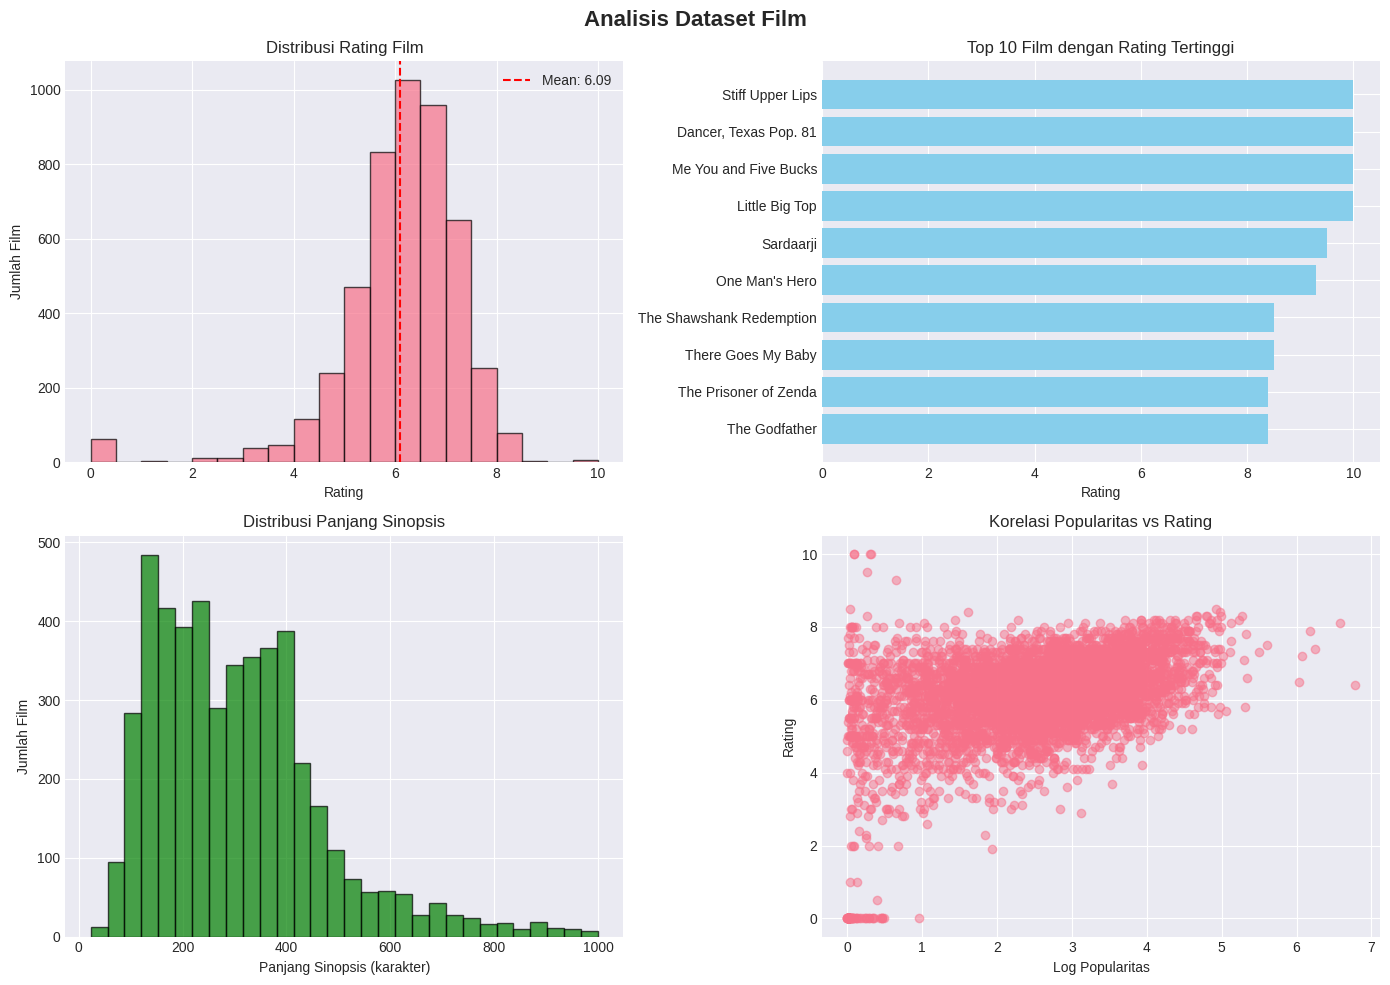


=== STATISTIK RINGKASAN ===

Total film: 4799
Rata-rata rating: 6.09
Median rating: 6.20
Rata-rata panjang sinopsis: 305 karakter
Film dengan rating tertinggi: Stiff Upper Lips (10.0)
Film dengan rating terendah: Black Water Transit (0.0)


In [ ]:
# ============================================
# CELL 10: Analisis Statistik Dataset Film
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Buat figure dengan subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analisis Dataset Film', fontsize=16, fontweight='bold')

# 1. Distribusi Rating Film
axes[0,0].hist(df_movies_clean['vote_average'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Distribusi Rating Film')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Jumlah Film')
axes[0,0].axvline(df_movies_clean['vote_average'].mean(), color='red', linestyle='--', label=f'Mean: {df_movies_clean["vote_average"].mean():.2f}')
axes[0,0].legend()

# 2. Top 10 Film dengan Rating Tertinggi
top_rated = df_movies_clean.nlargest(10, 'vote_average')[['title', 'vote_average']]
axes[0,1].barh(top_rated['title'], top_rated['vote_average'], color='skyblue')
axes[0,1].set_title('Top 10 Film dengan Rating Tertinggi')
axes[0,1].set_xlabel('Rating')
axes[0,1].invert_yaxis()

# 3. Distribusi Panjang Sinopsis
df_movies_clean['synopsis_length'] = df_movies_clean['overview'].fillna('').str.len()
axes[1,0].hist(df_movies_clean['synopsis_length'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1,0].set_title('Distribusi Panjang Sinopsis')
axes[1,0].set_xlabel('Panjang Sinopsis (karakter)')
axes[1,0].set_ylabel('Jumlah Film')

# 4. Korelasi Rating dengan Popularitas
# Konversi popularity dan vote_count ke log untuk visualisasi lebih baik
df_movies_clean['log_popularity'] = np.log1p(df_movies_clean['popularity'])
df_movies_clean['log_vote_count'] = np.log1p(df_movies_clean['vote_count'])

axes[1,1].scatter(df_movies_clean['log_popularity'], df_movies_clean['vote_average'], alpha=0.5)
axes[1,1].set_title('Korelasi Popularitas vs Rating')
axes[1,1].set_xlabel('Log Popularitas')
axes[1,1].set_ylabel('Rating')

plt.tight_layout()
plt.show()

# Tampilkan statistik ringkasan
print("\n=== STATISTIK RINGKASAN ===\n")
print(f"Total film: {len(df_movies_clean)}")
print(f"Rata-rata rating: {df_movies_clean['vote_average'].mean():.2f}")
print(f"Median rating: {df_movies_clean['vote_average'].median():.2f}")
print(f"Rata-rata panjang sinopsis: {df_movies_clean['synopsis_length'].mean():.0f} karakter")
print(f"Film dengan rating tertinggi: {df_movies_clean.loc[df_movies_clean['vote_average'].idxmax(), 'title']} ({df_movies_clean['vote_average'].max():.1f})")
print(f"Film dengan rating terendah: {df_movies_clean.loc[df_movies_clean['vote_average'].idxmin(), 'title']} ({df_movies_clean['vote_average'].min():.1f})")

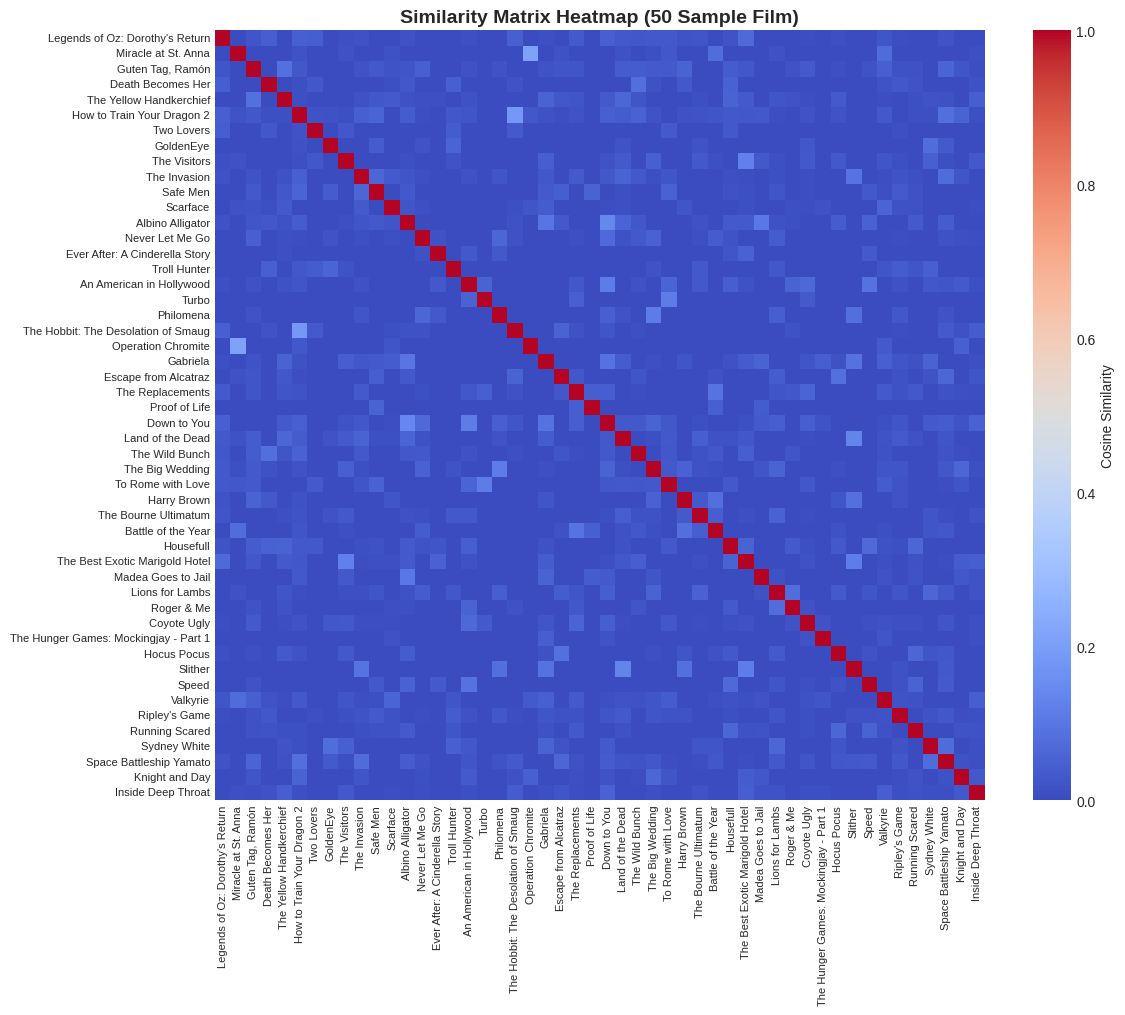

In [ ]:
# ============================================
# CELL 11: Visualisasi Similarity Matrix
# ============================================

# Visualisasi similarity matrix untuk sample film
n_sample = 50
sample_indices = np.random.choice(len(df_movies_clean), min(n_sample, len(df_movies_clean)), replace=False)
sample_sim_matrix = cosine_sim[np.ix_(sample_indices, sample_indices)]
sample_titles = df_movies_clean.iloc[sample_indices]['title'].tolist()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(sample_sim_matrix,
            xticklabels=sample_titles,
            yticklabels=sample_titles,
            cmap='coolwarm',
            center=0.5,
            square=True,
            cbar_kws={'label': 'Cosine Similarity'})
plt.title(f'Similarity Matrix Heatmap ({n_sample} Sample Film)', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# CELL 12: Prediksi Genre Berdasarkan Sinopsis
# ============================================

# Ekstrak genre dari dataset
import json

def extract_genres(genres_str):
    """Ekstrak genre dari string JSON"""
    try:
        genres_list = json.loads(genres_str.replace("'", '"'))
        return [g['name'] for g in genres_list]
    except:
        return []

df_movies_clean['genre_list'] = df_movies_clean['genres'].apply(extract_genres)
df_movies_clean['primary_genre'] = df_movies_clean['genre_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')

# Tampilkan distribusi genre
print("Distribusi Genre Film:")
genre_counts = df_movies_clean['primary_genre'].value_counts().head(10)
for genre, count in genre_counts.items():
    print(f"  {genre}: {count} film")

# Contoh prediksi genre untuk film baru (simulasi)
def predict_genre_by_keywords(overview, df):
    """
    Prediksi genre berdasarkan kata kunci di sinopsis
    """
    genre_keywords = {
        'Action': ['fight', 'battle', 'war', 'explosion', 'weapon', 'combat'],
        'Comedy': ['funny', 'humor', 'laugh', 'joke', 'hilarious', 'comedy'],
        'Drama': ['emotional', 'family', 'relationship', 'struggle', 'conflict'],
        'Horror': ['scary', 'terror', 'fear', 'ghost', 'horror', 'killer'],
        'Sci-Fi': ['space', 'alien', 'future', 'robot', 'technology', 'sci-fi'],
        'Romance': ['love', 'romance', 'heart', 'couple', 'relationship']
    }

    overview_lower = overview.lower()
    scores = {}

    for genre, keywords in genre_keywords.items():
        score = sum(1 for kw in keywords if kw in overview_lower)
        scores[genre] = score

    # Ambil genre dengan score tertinggi
    if max(scores.values()) > 0:
        return max(scores, key=scores.get)
    return 'Unknown'

# Contoh prediksi
example_overview = "A young man must fight against evil forces to save the world from destruction"
predicted_genre = predict_genre_by_keywords(example_overview, df_movies_clean)
print(f"\nContoh prediksi genre:")
print(f"Sinopsis: {example_overview}")
print(f"Prediksi genre: {predicted_genre}")

Distribusi Genre Film:
  Drama: 1206 film
  Comedy: 1042 film
  Action: 753 film
  Adventure: 339 film
  Horror: 300 film
  Crime: 195 film
  Thriller: 194 film
  Animation: 123 film
  Fantasy: 117 film
  Romance: 106 film

Contoh prediksi genre:
Sinopsis: A young man must fight against evil forces to save the world from destruction
Prediksi genre: Action


In [ ]:
import pickle
from google.colab import files
from scipy.sparse import save_npz, csr_matrix # Import csr_matrix

# Simpan model TF-IDF vectorizer
print("Menyimpan model...")

# Simpan vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Simpan similarity matrix (dalam bentuk sparse)
# Convert to sparse matrix before saving
save_npz('cosine_similarity_matrix.npz', csr_matrix(cosine_sim))

# Simpan dataframe yang sudah diproses
df_movies_clean.to_csv('processed_movies.csv', index=False)

print("Model dan data berhasil disimpan!")
print("\nFile yang disimpan:")
print("1. tfidf_vectorizer.pkl - Vectorizer TF-IDF")
print("2. cosine_similarity_matrix.npz - Matrix similarity")
print("3. processed_movies.csv - Data film yang sudah diproses")

# Download file untuk user
print("\n" + "="*40)
print("DOWNLOAD FILE")
print("="*40)

download = input("Apakah Anda ingin mendownload file yang telah disimpan? (y/n): ")
if download.lower() == 'y':
    files.download('tfidf_vectorizer.pkl')
    files.download('cosine_similarity_matrix.npz')
    files.download('processed_movies.csv')
    print("Proses download dimulai!")
else:
    print("File tersimpan di Google Colab environment.")

Menyimpan model...
Model dan data berhasil disimpan!

File yang disimpan:
1. tfidf_vectorizer.pkl - Vectorizer TF-IDF
2. cosine_similarity_matrix.npz - Matrix similarity
3. processed_movies.csv - Data film yang sudah diproses

DOWNLOAD FILE
Apakah Anda ingin mendownload file yang telah disimpan? (y/n): y


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Proses download dimulai!


In [ ]:
# ============================================
# CELL 14: Fungsi Rekomendasi dengan Filter
# ============================================

def get_filtered_recommendations(title, df, cosine_sim, min_rating=0, min_votes=0, n_recommendations=5):
    """
    Rekomendasi film dengan filter rating dan vote minimum

    Parameters:
    - title: judul film
    - df: dataframe
    - cosine_sim: similarity matrix
    - min_rating: rating minimum
    - min_votes: jumlah vote minimum
    - n_recommendations: jumlah rekomendasi
    """
    idx = df[df['title'].str.lower() == title.lower()].index

    if len(idx) == 0:
        print(f"Film '{title}' tidak ditemukan!")
        return None

    idx = idx[0]

    # Ambil semua similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Filter rekomendasi berdasarkan rating dan vote count
    recommendations = []
    for i, score in sim_scores[1:]:  # Skip film itu sendiri
        movie = df.iloc[i]
        if movie['vote_average'] >= min_rating and movie['vote_count'] >= min_votes:
            recommendations.append({
                'title': movie['title'],
                'similarity': score,
                'rating': movie['vote_average'],
                'votes': movie['vote_count'],
                'year': pd.to_datetime(movie['release_date'], errors='coerce').year
            })
        if len(recommendations) >= n_recommendations:
            break

    return pd.DataFrame(recommendations)

# Contoh penggunaan dengan filter
print("="*50)
print("REKOMENDASI DENGAN FILTER")
print("="*50)

recommendations_filtered = get_filtered_recommendations(
    "The Dark Knight Rises",
    df_movies_clean,
    cosine_sim,
    min_rating=7.0,
    min_votes=1000,
    n_recommendations=5
)

if recommendations_filtered is not None:
    print("\nRekomendasi untuk 'The Dark Knight Rises' (rating > 7.0, votes > 1000):")
    print(recommendations_filtered.to_string(index=False))

REKOMENDASI DENGAN FILTER

Rekomendasi untuk 'The Dark Knight Rises' (rating > 7.0, votes > 1000):
              title  similarity  rating  votes  year
    The Dark Knight    0.371185     8.2  12002  2008
             Batman    0.353388     7.0   2096  1989
      Batman Begins    0.205716     7.5   7359  2005
Law Abiding Citizen    0.143993     7.2   1486  2009
         District 9    0.081327     7.3   3382  2009
